In [2]:
!git clone https://github.com/Fgram-devAI/deepl-cifar100-image-analysis.git

fatal: destination path 'deepl-cifar100-image-analysis' already exists and is not an empty directory.


### Clone the Repository

In [3]:
%cd /content/deepl-cifar100-image-analysis

/content/deepl-cifar100-image-analysis


### Change Directory

In [4]:
!git checkout -b experiment/efficientnet-b0

Switched to a new branch 'experiment/efficientnet-b0'


### Create New Git Branch

In [5]:
!pwd

/content/deepl-cifar100-image-analysis


### Current Working Directory

### Install Dependencies (Implicit)

In [6]:
import sklearn, numpy, yaml, datasets
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.6.1
numpy: 2.0.2


### Verify Library Versions

### Fixing `numpy` compatibility issue

The `ValueError: numpy.dtype size changed` error typically indicates an incompatibility between different versions of `numpy` and other scientific computing libraries like `scikit-learn` or `scipy`. I will reinstall `numpy` and `scipy` to ensure that compatible versions are used. This often resolves such binary incompatibility errors.

### Project Structure

Now that the environment issues are addressed, let's look at the directory structure of the cloned repository to understand the project layout.

In [7]:
# List the contents of the current directory to show the project structure
!ls -R

.:
configs     experiments  pytest.ini		 requirements.txt  training
data	    models	 README.md		 results
evaluation  notebooks	 requirements-macos.txt  tests

./configs:
base.yaml    binary	multiclass  transfer	   vit.yaml
bilstm.yaml  lstm.yaml	rnn.yaml    transfer.yaml

./configs/binary:
coarse	fine

./configs/binary/coarse:
baseline_cnn_aquatic_mammals.yaml  baseline_cnn_food_containers.yaml
baseline_cnn_fish.yaml		   baseline_cnn_people.yaml
baseline_cnn_flowers.yaml

./configs/binary/fine:
baseline_cnn_cow.yaml		    baseline_cnn_orange.yaml
baseline_cnn_mushroom.yaml	    baseline_cnn_skyscraper.yaml
baseline_cnn_orange_aug_light.yaml  baseline_cnn_snake.yaml

./configs/multiclass:
baseline_cnn_coarse.yaml  baseline_cnn_fine.yaml

./configs/transfer:
resnet_family

./configs/transfer/resnet_family:
binary	multiclass

./configs/transfer/resnet_family/binary:
coarse	fine

./configs/transfer/resnet_family/binary/coarse:
resnet50v2_food_containers.yaml

./configs/transfer/resnet_family

### List Project Structure

### Baseline Model: EfficientNetB0

The `efficientnet_b0.py` file defines the `build_efficientnet_b0` function, which constructs a transfer-learning model based on the EfficientNetB0 architecture for CIFAR-100 image classification. Here's a breakdown of its information flow and key components:

In [8]:
import tensorflow as tf
from models.augmentation import build_augmentation

keras = tf.keras
layers = tf.keras.layers

def build_efficientnet_b0(
    input_shape: tuple[int, int, int] = (32, 32, 3),
    num_classes: int = 20,
    dropout: float = 0.3,
    freeze_backbone: bool = True,
    input_size: int = 96,
    augmentation: dict | None = None,
) -> keras.Model:
    inputs = keras.Input(shape=input_shape, name="image")

    # 1. Augmentation Layer (Optional)
    # If 'augmentation' is provided, an augmentation layer is built and applied.
    # This layer applies data augmentation techniques (e.g., random flips, rotations) to the input images
    # to increase the diversity of the training data and improve model generalization.
    aug_layer = build_augmentation(augmentation)
    x = aug_layer(inputs) if aug_layer is not None else inputs

    # 2. Input Resizing
    # The CIFAR-100 images are 32x32 pixels. EfficientNetB0, pre-trained on ImageNet,
    # expects larger input sizes. This layer resizes the 32x32 images to (input_size, input_size),
    # which defaults to 96x96 pixels in this model.
    x = layers.Resizing(input_size, input_size, interpolation="bilinear")(x)

    # 3. Input Rescaling
    # EfficientNetB0 expects pixel values in the range [0, 255] (raw pixel values),
    # as it has its own internal normalization layers. This layer scales the pixel values to this range.
    x = layers.Rescaling(255.0)(x)

    # 4. EfficientNetB0 Backbone
    # The core of the model is the EfficientNetB0 pre-trained on the ImageNet dataset.
    # `include_top=False` means the classification head of the original EfficientNetB0 is not included.
    # `weights="imagenet"` loads the pre-trained weights.
    # `input_shape` is set to the resized input dimensions.
    # `pooling="avg"` applies global average pooling to the output of the backbone, reducing spatial dimensions to a single vector.
    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_size, input_size, 3),
        pooling="avg",
    )
    # `freeze_backbone` controls whether the weights of the EfficientNetB0 backbone are trainable.
    # If True (default), the backbone weights are frozen, and only the new classification head is trained.
    # This is a common practice in transfer learning to leverage pre-learned features.
    backbone.trainable = not freeze_backbone

    # 5. Backbone Output
    # The processed images are passed through the EfficientNetB0 backbone.
    x = backbone(x, training=not freeze_backbone)

    # 6. Dropout Layer
    # A dropout layer is added to prevent overfitting. During training, a fraction of the neurons
    # are randomly set to zero, forcing the network to learn more robust features.
    x = layers.Dropout(dropout)(x)

    # 7. Classification Head
    # A dense (fully connected) layer with `num_classes` units is added as the classification head.
    # `activation="softmax"` is used for multi-class classification, outputting probabilities for each class.
    outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)

    # 8. Model Output
    # The function returns a `keras.Model` that takes the `inputs` (original image) and produces the `outputs` (class probabilities).
    return keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_b0")

### Define EfficientNetB0 Model

In [9]:
%cd /content/deepl-cifar100-image-analysis

/content/deepl-cifar100-image-analysis


### Change Directory Again

In [10]:

%%writefile models/efficientnet_b0.py
"""EfficientNetB0 transfer-learning model for CIFAR-100 multiclass tasks."""

import tensorflow as tf

from models.augmentation import build_augmentation

keras = tf.keras
layers = tf.keras.layers


def build_efficientnet_b0(
    input_shape: tuple[int, int, int] = (32, 32, 3),
    num_classes: int = 20,
    dropout: float = 0.3,
    freeze_backbone: bool = True,
    input_size: int = 96,
    augmentation: dict | None = None,
) -> keras.Model:
    """Build an EfficientNetB0 transfer-learning classifier for CIFAR-100.

    Resizes 32x32 -> (input_size, input_size), rescales back to [0, 255]
    (EfficientNetB0 has its own internal Rescaling/Normalization layers
    that expect raw pixel values, unlike most keras.applications models),
    runs the ImageNet-pretrained backbone (optionally frozen), then a
    dropout + softmax head sized to num_classes. Returned uncompiled.
    """
    if num_classes < 1:
        raise ValueError(f"num_classes must be >= 1; got {num_classes}")

    inputs = keras.Input(shape=input_shape, name="image")

    aug_layer = build_augmentation(augmentation)
    x = aug_layer(inputs) if aug_layer is not None else inputs

    x = layers.Resizing(input_size, input_size, interpolation="bilinear")(x)
    x = layers.Rescaling(255.0)(x)

    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(input_size, input_size, 3),
        pooling="avg",
    )
    backbone.trainable = not freeze_backbone

    x = backbone(x, training=not freeze_backbone)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="prob")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="efficientnet_b0")

Writing models/efficientnet_b0.py


### Write EfficientNetB0 Model File

In [11]:
%%writefile models/__init__.py
"""Models module: sequential (RNN/LSTM/BiLSTM), ViT, transfer-learning, and baseline CNN architectures."""

from .baseline import build_baseline_cnn
from .efficientnet_b0 import build_efficientnet_b0
from .sequential import build_rnn, build_lstm, build_bilstm
from .vit import build_vit
from .transfer import build_transfer

__all__ = [
    "build_baseline_cnn",
    "build_efficientnet_b0",
    "build_rnn",
    "build_lstm",
    "build_bilstm",
    "build_vit",
    "build_transfer",
]

Overwriting models/__init__.py


### Update Models `__init__.py`

In [13]:
import pathlib
import re # Import the regular expression module

p = pathlib.Path("training/train.py")
src = p.read_text()

src = src.replace(
    "from models.baseline import build_baseline_cnn\n",
    "from models.baseline import build_baseline_cnn\n"
    "from models.efficientnet_b0 import build_efficientnet_b0\n",
)

# Dynamically extract old_build_model from src using a regular expression
# This makes the patch more robust to minor whitespace or comment changes in train.py
_BUILD_MODEL_REGEX = re.compile(
    r"^(def _build_model\(config: Dict\[str, Any\], \*, num_classes: int = 1\) -> tf.keras.Model:.*?(?=\n^[^ \t]|\Z))",
    re.DOTALL | re.MULTILINE
)

match = _BUILD_MODEL_REGEX.search(src)
if not match:
    raise ValueError(
        "The '_build_model' function could not be found in 'train.py' with the "
        "expected signature. 'train.py' might have undergone significant "
        "changes, and manual review of the patch is required."
    )
# Use the matched string as the old_build_model for replacement
old_build_model = match.group(0)

new_build_model = '''def _build_model(config: Dict[str, Any], *, num_classes: int = 1) -> tf.keras.Model:
    architecture = config.get("architecture", "baseline_cnn")
    if architecture == "baseline_cnn":
        return build_baseline_cnn(
            dropout=float(config.get("dropout", 0.3)),
            num_classes=num_classes,
            augmentation=config.get("augmentation"),
        )
    if architecture == "efficientnet_b0":
        return build_efficientnet_b0(
            dropout=float(config.get("dropout", 0.3)),
            num_classes=num_classes,
            freeze_backbone=bool(config.get("freeze_backbone", True)),
            input_size=int(config.get("input_size", 96)),
            augmentation=config.get("augmentation"),
        )
    raise ValueError(
        f"Unsupported architecture {architecture!r}. "
        "Supported architectures are 'baseline_cnn' and 'efficientnet_b0'."
    )'''

# The assertion `assert old_build_model in src` is no longer needed since old_build_model is now extracted from src.
src = src.replace(old_build_model, new_build_model)
p.write_text(src)
print("train.py patched.")

train.py patched.


### Patch `train.py` to Include EfficientNetB0

In [14]:
%%writefile configs/multiclass/efficientnet_b0_coarse.yaml
architecture: efficientnet_b0
run_name: efficientnet_b0_coarse_lr_1e-3_epochs_10
seed: 42

task:
  type: multiclass
  label_level: coarse

validation:
  fraction: 0.1

class_imbalance:
  strategy: none

batch_size: 32
shuffle_buffer: 4096
dropout: 0.3
epochs: 10
optimizer: adam
learning_rate: 1e-3

freeze_backbone: true
input_size: 96

early_stopping:
  monitor: val_loss
  patience: 5

output_dir: results/efficientnet_b0_coarse
save_weights: true
subset_size: null

Writing configs/multiclass/efficientnet_b0_coarse.yaml


### Create EfficientNetB0 Coarse Configuration File

In [15]:
!ls models/ | grep efficientnet
!grep efficientnet_b0 models/__init__.py
!grep efficientnet_b0 training/train.py
!ls configs/multiclass/

efficientnet_b0.py
from .efficientnet_b0 import build_efficientnet_b0
    "build_efficientnet_b0",
from models.efficientnet_b0 import build_efficientnet_b0
    if architecture == "efficientnet_b0":
        return build_efficientnet_b0(
        "Supported architectures are 'baseline_cnn' and 'efficientnet_b0'."
baseline_cnn_coarse.yaml  baseline_cnn_fine.yaml  efficientnet_b0_coarse.yaml


### Verify EfficientNetB0 Integration

In [16]:
!pip install -q tf_keras

### Install `tf_keras`

In [17]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

### Set TensorFlow Keras Legacy Flag

### Placeholder for Additional Setup

In [18]:
!python -m training.train --config configs/multiclass/efficientnet_b0_coarse.yaml

README.md: 100% 9.98k/9.98k [00:00<00:00, 20.9MB/s]
cifar100/train-00000-of-00001.parquet: 100% 119M/119M [00:01<00:00, 70.3MB/s]
cifar100/test-00000-of-00001.parquet: 100% 23.8M/23.8M [00:00<00:00, 25.0MB/s]
Generating train split: 100% 50000/50000 [00:00<00:00, 85073.12 examples/s] 
Generating test split: 100% 10000/10000 [00:00<00:00, 70364.78 examples/s]
2026-06-21 19:15:45.152198: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782069345.153640    1416 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-06-21 19:15:45.154640: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.
2026-06-21 19:15:45.658633: W external/local_xla/x

### Run Training with EfficientNetB0

In [19]:
!ls -la results/efficientnet_b0_coarse/

total 12
drwxr-xr-x 3 root root 4096 Jun 21 19:15 .
drwxr-xr-x 3 root root 4096 Jun 21 19:15 ..
drwxr-xr-x 2 root root 4096 Jun 21 19:20 efficientnet_b0_coarse_lr_1e-3_epochs_10


### List Training Results Directory

In [20]:
import json
from pathlib import Path

# Update run_dir to point to the actual directory containing history.json and metrics.json
run_dir = Path("results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10")

with open(run_dir / "history.json") as f:
    history = json.load(f)

with open(run_dir / "metrics.json") as f:
    metrics = json.load(f);

print("History keys:", list(history.keys()))
print("Metrics keys:", list(metrics.keys()))

History keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy']
Metrics keys: ['accuracy', 'top_3_accuracy', 'top_5_accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_precision', 'weighted_recall', 'weighted_f1', 'confusion_matrix', 'class_counts']


### Load Training History and Metrics

In [21]:
print("=== Final test metrics (efficientnet_b0_coarse) ===")
print(f"Accuracy:        {metrics['accuracy']:.4f}")
if "top_3_accuracy" in metrics:
    print(f"Top-3 accuracy:  {metrics['top_3_accuracy']:.4f}")
if "top_5_accuracy" in metrics:
    print(f"Top-5 accuracy:  {metrics['top_5_accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")
print(f"Weighted F1:     {metrics['weighted_f1']:.4f}")

=== Final test metrics (efficientnet_b0_coarse) ===
Accuracy:        0.7396
Top-3 accuracy:  0.9129
Top-5 accuracy:  0.9580
Macro precision: 0.7388
Macro recall:    0.7396
Macro F1:        0.7385
Weighted F1:     0.7385


### Print Final Test Metrics

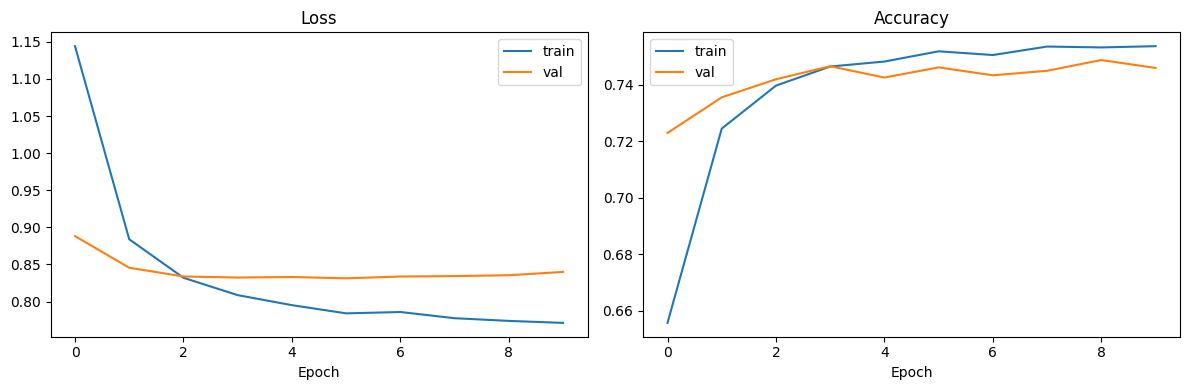

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["accuracy"], label="train")
axes[1].plot(history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150)
plt.show()

### Plot Training Curves (Loss and Accuracy)

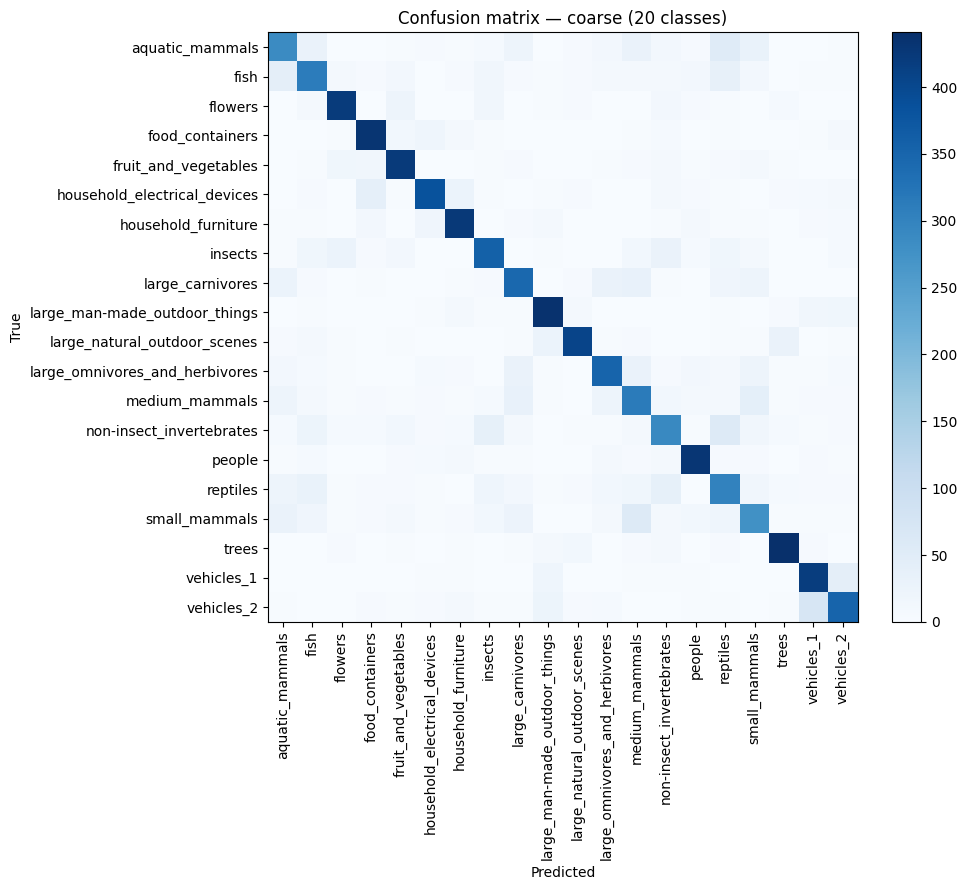

In [23]:
import numpy as np

COARSE_LABELS = [
    "aquatic_mammals", "fish", "flowers", "food_containers",
    "fruit_and_vegetables", "household_electrical_devices",
    "household_furniture", "insects", "large_carnivores",
    "large_man-made_outdoor_things", "large_natural_outdoor_scenes",
    "large_omnivores_and_herbivores", "medium_mammals",
    "non-insect_invertebrates", "people", "reptiles", "small_mammals",
    "trees", "vehicles_1", "vehicles_2",
]

cm = np.array(metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(20)); ax.set_xticklabels(COARSE_LABELS, rotation=90)
ax.set_yticks(range(20)); ax.set_yticklabels(COARSE_LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix — coarse (20 classes)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(run_dir / "confusion_matrix.png", dpi=150)
plt.show()

### Plot Confusion Matrix for Coarse Classes

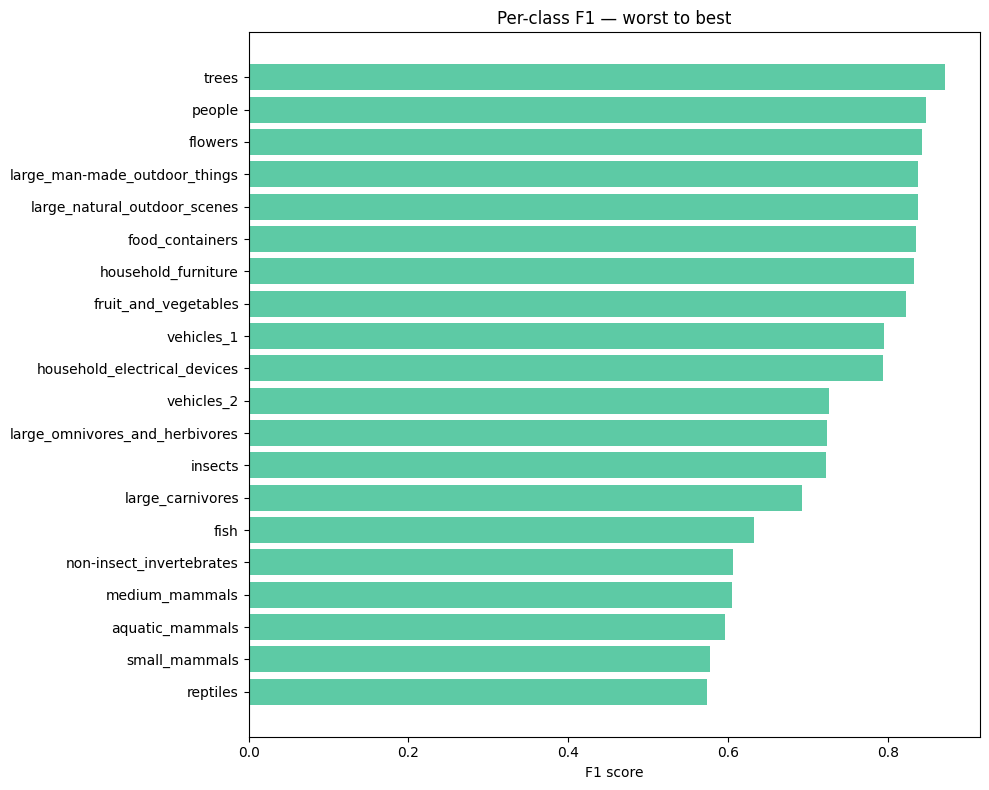

In [24]:
diag = np.diag(cm)
col_sums = cm.sum(axis=0)
row_sums = cm.sum(axis=1)

precision = np.divide(diag, col_sums, out=np.zeros_like(diag, dtype=float), where=col_sums != 0)
recall = np.divide(diag, row_sums, out=np.zeros_like(diag, dtype=float), where=row_sums != 0)
f1 = np.divide(2 * precision * recall, precision + recall,
                out=np.zeros_like(diag, dtype=float), where=(precision + recall) != 0)

order = np.argsort(f1)  # worst classes first

fig, ax = plt.subplots(figsize=(10, 8))
y = np.arange(20)
ax.barh(y, f1[order], color="#5DCAA5")
ax.set_yticks(y)
ax.set_yticklabels([COARSE_LABELS[i] for i in order])
ax.set_xlabel("F1 score")
ax.set_title("Per-class F1 — worst to best")
plt.tight_layout()
plt.savefig(run_dir / "per_class_f1.png", dpi=150)
plt.show()

### Load CIFAR-100 Test Data

### Plot Per-Class F1 Score

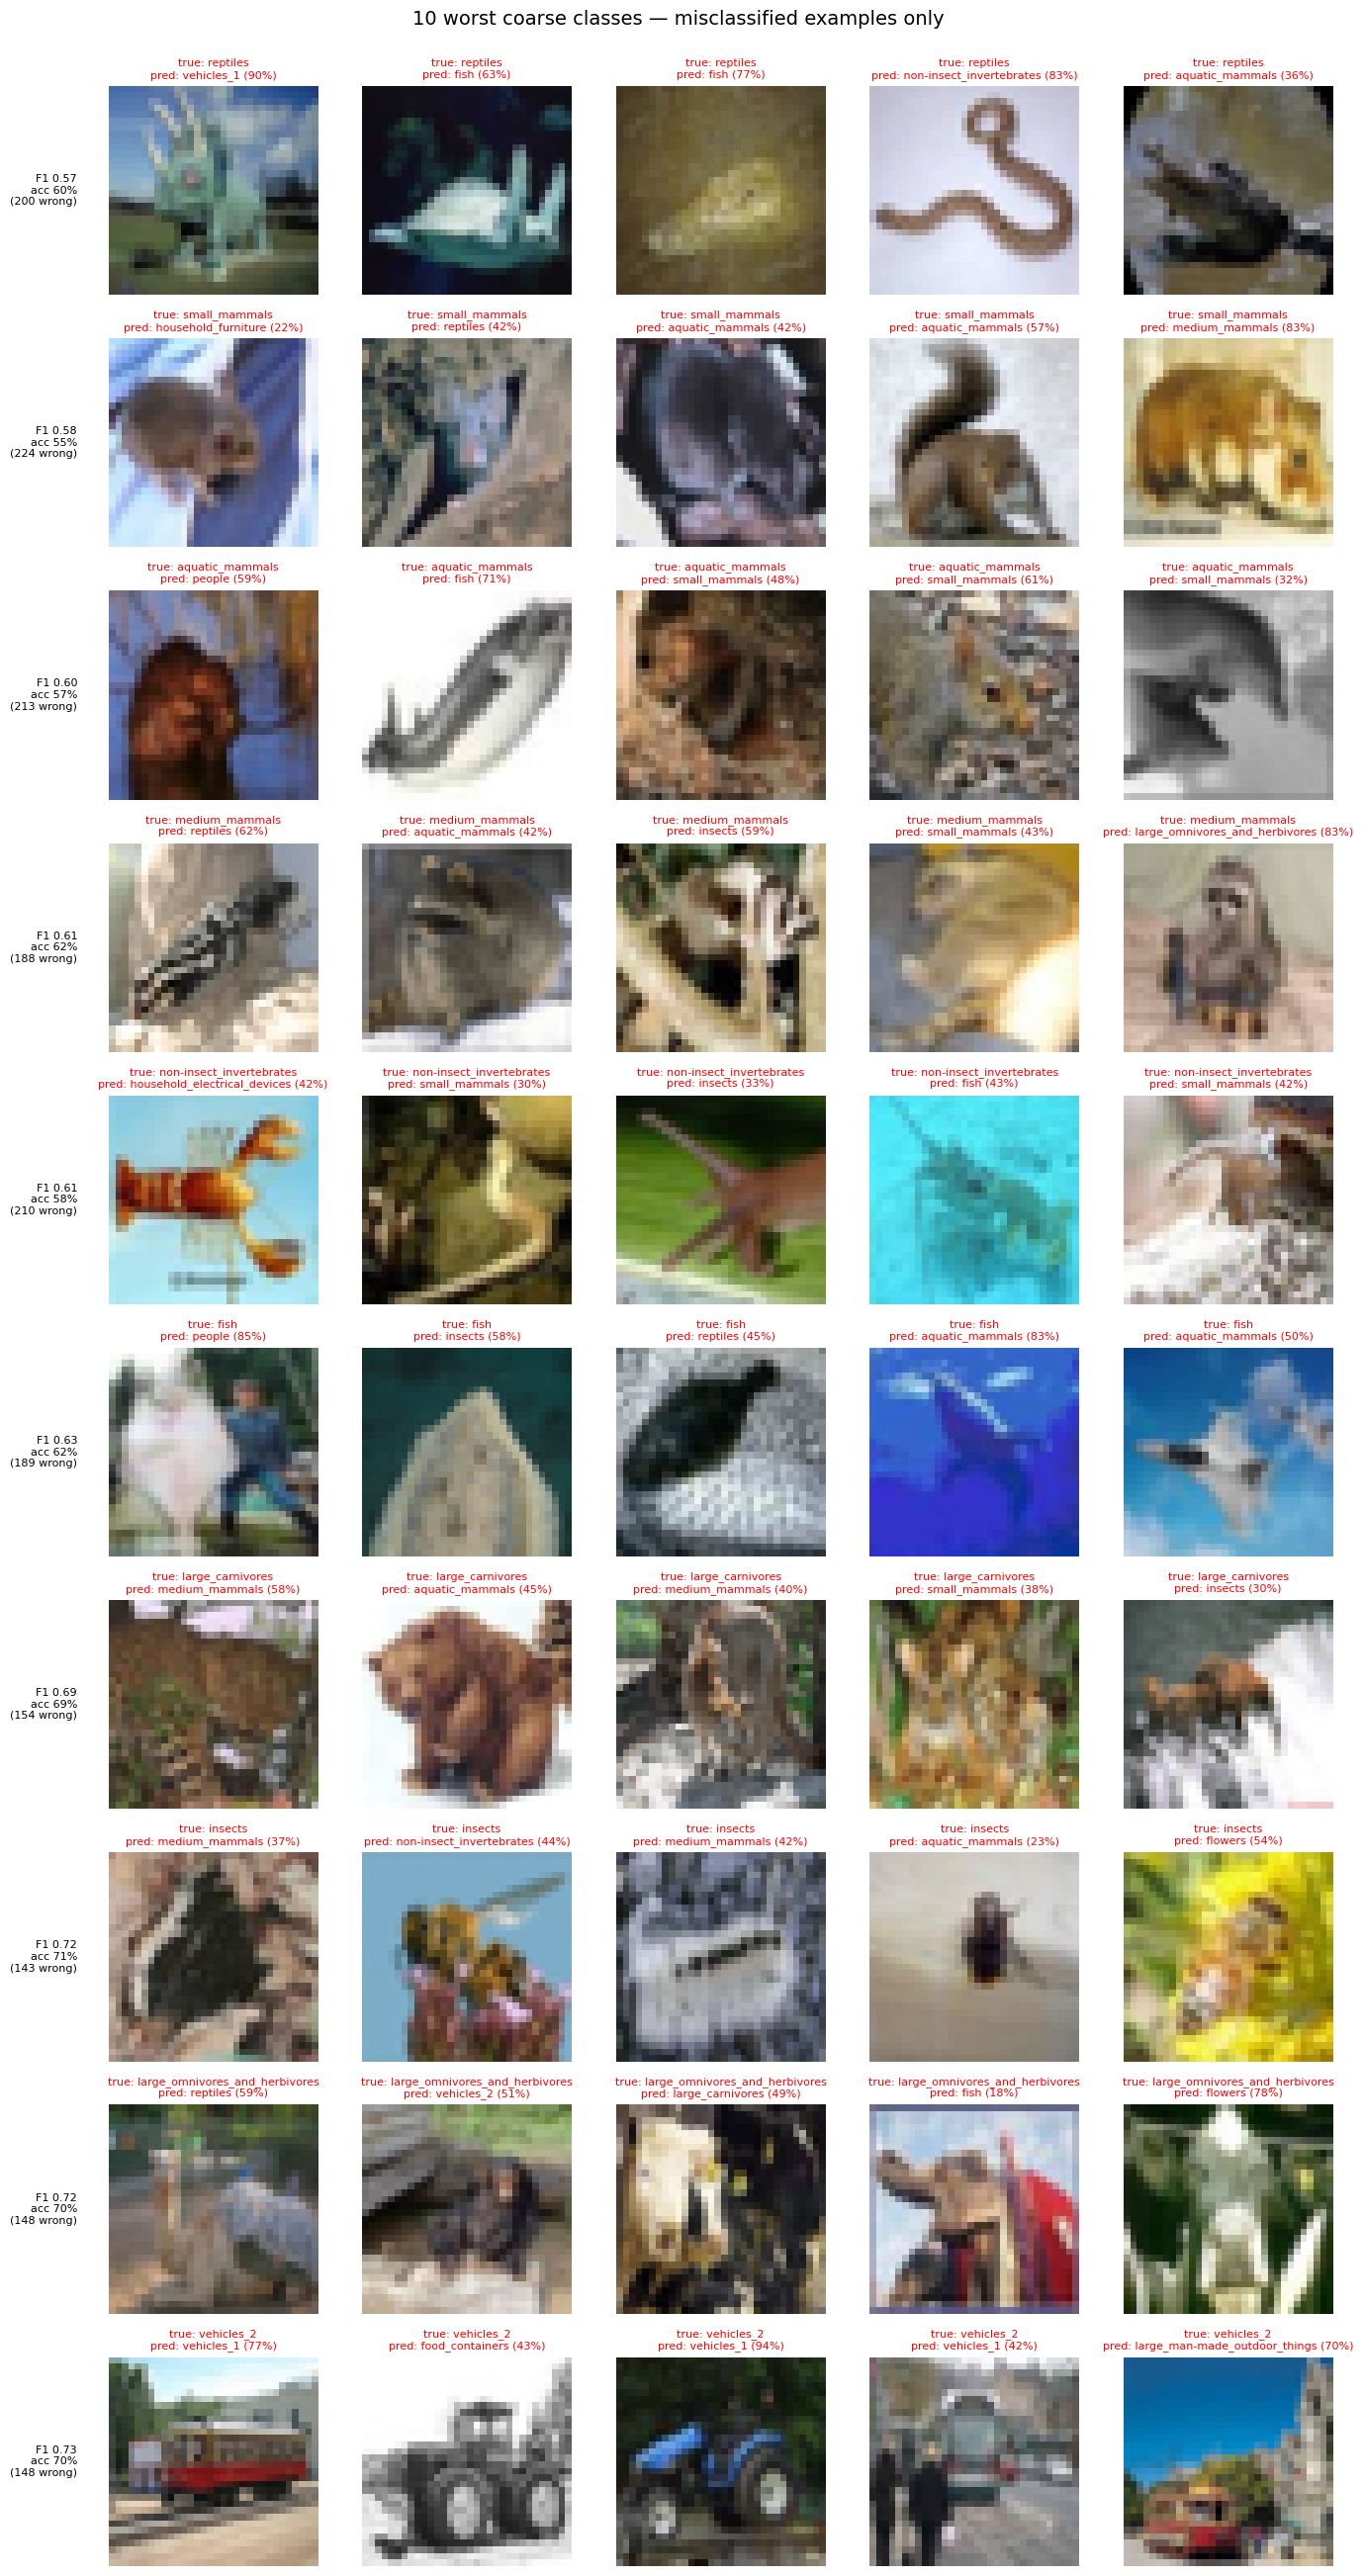

In [38]:
# Worst-10 misclassified examples grid με ground truth
fig, axes = plt.subplots(10, 5, figsize=(14, 26))

for row, cat_id in enumerate(worst10):
    category = COARSE_LABELS[cat_id]
    is_this_class = test_labels == cat_id
    wrong_idx = np.flatnonzero(is_this_class & (preds != cat_id))

    acc = (preds[is_this_class] == cat_id).mean()
    n_wrong = len(wrong_idx)

    shown = wrong_idx[:5]
    for col in range(5):
        ax = axes[row, col]
        if col < len(shown):
            idx = shown[col]
            ax.imshow(test_images[idx])
            ax.set_title(
                f"true: {category}\npred: {COARSE_LABELS[preds[idx]]} ({confidences[idx]:.0%})",
                fontsize=8, color="red"
            )
        ax.axis("off")
        if col == 0:
            ax.text(-0.15, 0.5, f"F1 {f1[cat_id]:.2f}\nacc {acc:.0%}\n({n_wrong} wrong)",
                     transform=ax.transAxes, fontsize=8, va="center", ha="right")

fig.suptitle("10 worst coarse classes — misclassified examples only", fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig(run_dir / "worst10_misclassified.png", dpi=150)
plt.show()

In [40]:
!git config --global user.email "thcoccas@gmail.com"
!git config --global user.name "ThodorisKokkas"

In [41]:
!git add -A

In [42]:
!git add -f results/efficientnet_b0_coarse/

In [43]:
!git status

On branch experiment/efficientnet-b0
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/class_balance.json
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/config.yaml
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/confusion_matrix.png
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/history.csv
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/history.json
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/metrics.json
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/per_class_f1.png
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/per_class_f1_worst10.png
	new file:   results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3

In [44]:
!git commit -m "Add worst-10 F1 chart and misclassified examples grid for EfficientNetB0 coarse"

[experiment/efficientnet-b0 88096f9] Add worst-10 F1 chart and misclassified examples grid for EfficientNetB0 coarse
 12 files changed, 628 insertions(+)
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/class_balance.json
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/config.yaml
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/confusion_matrix.png
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/history.csv
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/history.json
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/metrics.json
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/per_class_f1.png
 create mode 100644 results/efficientnet_b0_coarse/efficientnet_b0_coarse_lr_1e-3_epochs_10/per

In [45]:
from getpass import getpass
token = getpass("GitHub Personal Access Token:")

GitHub Personal Access Token:··········


In [ ]:
import json
from google.colab import _message

notebook_json = _message.blocking_request('get_ipynb', timeout_sec=30)
nb = notebook_json['ipynb']

with open('b0_20_classes.ipynb', 'w') as f:
    json.dump(nb, f, indent=1)
